In [1]:
!pip install -q transformers torch pillow bitsandbytes accelerate qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 65.7 MB/s eta 0:00:00


In [2]:
import os, json, random, math
from PIL import Image, ImageDraw

random.seed(42)
OUT_DIR = "data/synthetic"
os.makedirs(OUT_DIR, exist_ok=True)

CANVAS = 512
COLORS = ["red", "blue", "green", "orange", "purple", "brown"]

def place_grid_objects(n, canvas=CANVAS, jitter=0.3):
    """Place n non-overlapping objects on a jittered grid, guarantees exactly n objects, no rejection sampling."""
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)
    cell_w, cell_h = canvas / cols, canvas / rows
    radius = min(cell_w, cell_h) * 0.3
    positions = []
    count = 0
    for r in range(rows):
        for c in range(cols):
            if count >= n:
                break
            cx = c * cell_w + cell_w / 2 + random.uniform(-jitter, jitter) * cell_w * 0.3
            cy = r * cell_h + cell_h / 2 + random.uniform(-jitter, jitter) * cell_h * 0.3
            positions.append((cx, cy, radius))
            count += 1
    return positions

def draw_objects(positions, path):
    img = Image.new("RGB", (CANVAS, CANVAS), "white")
    draw = ImageDraw.Draw(img)
    for i, (cx, cy, r) in enumerate(positions):
        color = COLORS[i % len(COLORS)]
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color, outline="black")
    img.save(path)

def draw_occlusion_pair(alpha, canvas=CANVAS, n_pairs=4):
    """8 objects total (n_pairs=4 pairs), each pair's overlap controlled by alpha (0=no overlap, 0.75=75% overlap)."""
    img = Image.new("RGB", (canvas, canvas), "white")
    draw = ImageDraw.Draw(img)
    radius = 40
    positions = []
    cols = 2
    for p in range(n_pairs):
        base_x = (p % cols) * (canvas // cols) + canvas // (2 * cols)
        base_y = (p // cols) * (canvas // 2) + canvas // 4
        gap = (1 - alpha) * (2 * radius)
        cx1, cy1 = base_x - gap / 2, base_y
        cx2, cy2 = base_x + gap / 2, base_y
        for cx, cy in [(cx1, cy1), (cx2, cy2)]:
            color = COLORS[len(positions) % len(COLORS)]
            draw.ellipse([cx - radius, cy - radius, cx + radius, cy + radius], fill=color, outline="black")
            positions.append((cx, cy, radius))
    img.save(f"{OUT_DIR}/occlusion_{int(alpha*100)}.png")
    return positions

metadata = []

# Density sweep
for n in range(2, 17):
    positions = place_grid_objects(n)
    fname = f"{OUT_DIR}/density_{n:02d}.png"
    draw_objects(positions, fname)
    metadata.append({
        "image_id": f"density_{n:02d}",
        "path": fname,
        "count": n,
        "occlusion_ratio": 0.0,
        "sweep_type": "density"
    })

# Occlusion sweep: fixed N=8, overlap 0%, 25%, 50%, 75%
for alpha in [0.0, 0.25, 0.5, 0.75]:
    positions = draw_occlusion_pair(alpha)
    metadata.append({
        "image_id": f"occlusion_{int(alpha*100)}",
        "path": f"{OUT_DIR}/occlusion_{int(alpha*100)}.png",
        "count": 8,
        "occlusion_ratio": alpha,
        "sweep_type": "occlusion"
    })

with open(f"{OUT_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Generated {len(metadata)} images.")

Generated 19 images.


In [3]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

def load_qwen2vl_4bit(model_name="Qwen/Qwen2-VL-7B-Instruct", device="cuda"):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=False,
    )
    processor = AutoProcessor.from_pretrained(model_name)
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
    )
    model.eval()
    return model, processor

def run_vqa_and_get_hidden_states(model, processor, image, prompt="How many objects are in the image?", device="cuda"):
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(device)

    # Forward pass for clean per-layer hidden states
    with torch.no_grad():
        fwd_out = model(**inputs, output_hidden_states=True)
    all_hidden_states = fwd_out.hidden_states  # tuple: (num_layers+1) x [batch, seq_len, hidden_dim]

    attn_mask = inputs["attention_mask"][0]
    valid_mask = attn_mask == 1
    pooled_layers = []
    for layer_hidden in all_hidden_states:
        h = layer_hidden[0]
        valid_hidden = h[valid_mask]
        pooled = valid_hidden.mean(dim=0) if valid_hidden.shape[0] > 0 else h.mean(dim=0)
        pooled_layers.append(pooled.cpu())
    pooled_tensor = torch.stack(pooled_layers, dim=0)

    with torch.no_grad():
        gen_out = model.generate(**inputs, max_new_tokens=50)
    generated_text = processor.batch_decode(
        gen_out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]

    return generated_text, pooled_tensor

In [4]:
from PIL import Image

model, processor = load_qwen2vl_4bit()
img = Image.open("data/synthetic/density_05.png")
answer, hidden = run_vqa_and_get_hidden_states(model, processor, img)
print("Model answer:", answer)
print("Hidden states shape:", hidden.shape)

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Model answer: There are five objects in the image.
Hidden states shape: torch.Size([29, 3584])


In [5]:
import json
import torch

with open("data/synthetic/metadata.json") as f:
    metadata = json.load(f)

results = []
all_hidden = []

for item in metadata:
    img = Image.open(item["path"])
    answer, hidden = run_vqa_and_get_hidden_states(model, processor, img)
    print(f"{item['image_id']}: true_count={item['count']}, model_said='{answer.strip()}'")
    results.append({
        "image_id": item["image_id"],
        "true_count": item["count"],
        "occlusion_ratio": item["occlusion_ratio"],
        "sweep_type": item["sweep_type"],
        "model_answer": answer.strip(),
    })
    all_hidden.append(hidden)

hidden_tensor = torch.stack(all_hidden, dim=0)
torch.save(hidden_tensor, "data/synthetic/hidden_states.pt")

with open("data/synthetic/results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\nDone. Hidden states tensor shape: {hidden_tensor.shape}")

density_02: true_count=2, model_said='There are two objects in the image.'
density_03: true_count=3, model_said='There are three objects in the image.'
density_04: true_count=4, model_said='There are four objects in the image.'
density_05: true_count=5, model_said='There are five objects in the image.'
density_06: true_count=6, model_said='There are six objects in the image.'
density_07: true_count=7, model_said='There are seven objects in the image.'
density_08: true_count=8, model_said='There are 9 objects in the image.'
density_09: true_count=9, model_said='There are 9 objects in the image.'
density_10: true_count=10, model_said='There are 9 objects in the image.'
density_11: true_count=11, model_said='There are 10 objects in the image.'
density_12: true_count=12, model_said='There are 12 objects in the image.'
density_13: true_count=13, model_said='There are 13 objects in the image.'
density_14: true_count=14, model_said='There are 15 objects in the image.'
density_15: true_count=1

In [6]:
import os; os.makedirs("results", exist_ok=True)

Layer  0: probe MAE=0.56  R2=0.96  control_MAE=2.19
Layer  1: probe MAE=0.56  R2=0.96  control_MAE=2.16
Layer  2: probe MAE=0.56  R2=0.96  control_MAE=2.14
Layer  3: probe MAE=0.57  R2=0.96  control_MAE=2.14
Layer  4: probe MAE=0.57  R2=0.96  control_MAE=2.13
Layer  5: probe MAE=0.56  R2=0.96  control_MAE=2.11
Layer  6: probe MAE=0.56  R2=0.96  control_MAE=2.14
Layer  7: probe MAE=0.55  R2=0.96  control_MAE=2.11
Layer  8: probe MAE=0.51  R2=0.96  control_MAE=2.16
Layer  9: probe MAE=0.51  R2=0.97  control_MAE=2.27
Layer 10: probe MAE=0.51  R2=0.97  control_MAE=2.27
Layer 11: probe MAE=0.51  R2=0.97  control_MAE=2.30
Layer 12: probe MAE=0.45  R2=0.97  control_MAE=2.30
Layer 13: probe MAE=0.43  R2=0.98  control_MAE=2.27
Layer 14: probe MAE=0.40  R2=0.98  control_MAE=2.33
Layer 15: probe MAE=0.42  R2=0.98  control_MAE=2.26
Layer 16: probe MAE=0.38  R2=0.98  control_MAE=2.36
Layer 17: probe MAE=0.38  R2=0.98  control_MAE=2.41
Layer 18: probe MAE=0.37  R2=0.98  control_MAE=2.51
Layer 19: pr

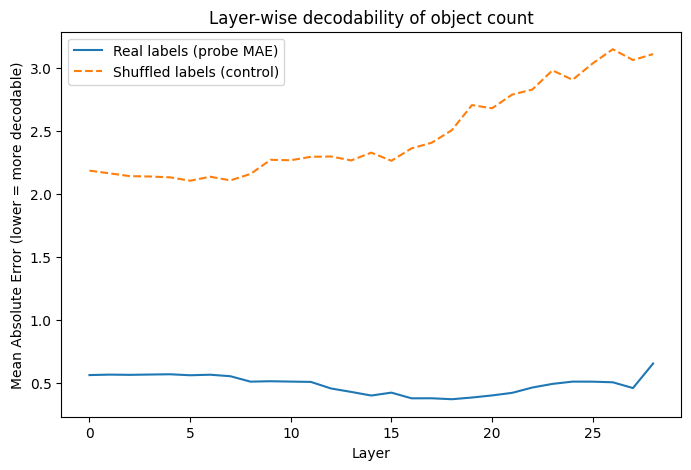

In [7]:
import json
import numpy as np
import torch
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

hidden_tensor = torch.load("data/synthetic/hidden_states.pt").float()
with open("data/synthetic/results.json") as f:
    results = json.load(f)

y_true = np.array([r["true_count"] for r in results])
num_images, num_layers, hidden_dim = hidden_tensor.shape

# NOTE: 19 samples is very small: using regression + leave-one-out CV
# instead of multiclass classification, since 15 possible count values
# with 19 samples would be too sparse to classify meaningfully.

loo = LeaveOneOut()
layer_mae = []
layer_r2 = []
control_mae = []

y_shuffled = y_true.copy()
np.random.seed(0)
np.random.shuffle(y_shuffled)

for layer in range(num_layers):
    X = hidden_tensor[:, layer, :].numpy()

    preds = cross_val_predict(Ridge(alpha=1.0), X, y_true, cv=loo)
    layer_mae.append(mean_absolute_error(y_true, preds))
    layer_r2.append(r2_score(y_true, preds))

    control_preds = cross_val_predict(Ridge(alpha=1.0), X, y_shuffled, cv=loo)
    control_mae.append(mean_absolute_error(y_shuffled, control_preds))

for l in range(num_layers):
    print(f"Layer {l:2d}: probe MAE={layer_mae[l]:.2f}  R2={layer_r2[l]:.2f}  control_MAE={control_mae[l]:.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(layer_mae, label="Real labels (probe MAE)")
plt.plot(control_mae, label="Shuffled labels (control)", linestyle="--")
plt.xlabel("Layer")
plt.ylabel("Mean Absolute Error (lower = more decodable)")
plt.title("Layer-wise decodability of object count")
plt.legend()
plt.savefig("results/act1_probe_curve.png", dpi=150)
plt.show()

In [8]:
best_layer = 17  # pick the layer with lowest MAE from your printout
X_best = hidden_tensor[:, best_layer, :].float().numpy()
preds_best = cross_val_predict(Ridge(alpha=1.0), X_best, y_true, cv=loo)

for r, pred in zip(results, preds_best):
    flag = " <-- model got this wrong" if str(r["true_count"]) not in r["model_answer"] else ""
    print(f"{r['image_id']}: true={r['true_count']}, probe_pred={pred:.1f}, model_said='{r['model_answer']}'{flag}")

density_02: true=2, probe_pred=2.1, model_said='There are two objects in the image.' <-- model got this wrong
density_03: true=3, probe_pred=3.2, model_said='There are three objects in the image.' <-- model got this wrong
density_04: true=4, probe_pred=5.1, model_said='There are four objects in the image.' <-- model got this wrong
density_05: true=5, probe_pred=4.6, model_said='There are five objects in the image.' <-- model got this wrong
density_06: true=6, probe_pred=6.2, model_said='There are six objects in the image.' <-- model got this wrong
density_07: true=7, probe_pred=7.0, model_said='There are seven objects in the image.' <-- model got this wrong
density_08: true=8, probe_pred=8.3, model_said='There are 9 objects in the image.' <-- model got this wrong
density_09: true=9, probe_pred=9.1, model_said='There are 9 objects in the image.'
density_10: true=10, probe_pred=9.6, model_said='There are 9 objects in the image.' <-- model got this wrong
density_11: true=11, probe_pred=11

In [9]:
import os, json, random, math
from PIL import Image, ImageDraw

random.seed(7)
OUT_DIR = "data/synthetic"
os.makedirs(OUT_DIR, exist_ok=True)
CANVAS = 512
COLORS = ["red", "blue", "green", "orange", "purple", "brown"]

def place_grid_objects(n, canvas=CANVAS, jitter=0.3, radius_override=None):
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)
    cell_w, cell_h = canvas / cols, canvas / rows
    radius = radius_override if radius_override else min(cell_w, cell_h) * 0.3
    positions = []
    count = 0
    for r in range(rows):
        for c in range(cols):
            if count >= n:
                break
            cx = c * cell_w + cell_w / 2 + random.uniform(-jitter, jitter) * cell_w * 0.3
            cy = r * cell_h + cell_h / 2 + random.uniform(-jitter, jitter) * cell_h * 0.3
            positions.append((cx, cy, radius))
            count += 1
    return positions

def draw_objects(positions, path):
    img = Image.new("RGB", (CANVAS, CANVAS), "white")
    draw = ImageDraw.Draw(img)
    for i, (cx, cy, r) in enumerate(positions):
        color = COLORS[i % len(COLORS)]
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color, outline="black")
    img.save(path)

metadata = []

# 1. Density sweep with 2 seeds per N (different jitter/positions)
for seed_idx in range(2):
    for n in range(2, 17):
        random.seed(100 + seed_idx * 50 + n)
        positions = place_grid_objects(n)
        fname = f"{OUT_DIR}/density_{n:02d}_s{seed_idx}.png"
        draw_objects(positions, fname)
        metadata.append({"image_id": f"density_{n:02d}_s{seed_idx}", "path": fname,
                          "count": n, "occlusion_ratio": 0.0, "sweep_type": "density", "radius": None})

# 2. Size-varied control: same set of N values, but radius randomized independent of count
for n in [3, 6, 9, 12, 15]:
    random.seed(200 + n)
    rand_radius = random.uniform(15, 45)
    positions = place_grid_objects(n, radius_override=rand_radius)
    fname = f"{OUT_DIR}/sizevaried_{n:02d}.png"
    draw_objects(positions, fname)
    metadata.append({"image_id": f"sizevaried_{n:02d}", "path": fname,
                      "count": n, "occlusion_ratio": 0.0, "sweep_type": "size_control", "radius": rand_radius})

# 3. Fixed occlusion sweep: true separated baseline at alpha=0, finer steps
def draw_occlusion_pair(alpha, canvas=CANVAS, n_pairs=4, radius=40):
    img = Image.new("RGB", (canvas, canvas), "white")
    draw = ImageDraw.Draw(img)
    positions = []
    cols = 2
    for p in range(n_pairs):
        base_x = (p % cols) * (canvas // cols) + canvas // (2 * cols)
        base_y = (p // cols) * (canvas // 2) + canvas // 4
        # alpha=-1.0 -> fully separated (gap = 1 full radius), alpha=0.75 -> 75% overlap
        # remap so alpha=0 means "just touching", negative alpha means real separation
        gap = (1 - max(alpha, 0)) * (2 * radius) if alpha >= 0 else (2 * radius) + abs(alpha) * radius
        cx1, cy1 = base_x - gap / 2, base_y
        cx2, cy2 = base_x + gap / 2, base_y
        for cx, cy in [(cx1, cy1), (cx2, cy2)]:
            color = COLORS[len(positions) % len(COLORS)]
            draw.ellipse([cx - radius, cy - radius, cx + radius, cy + radius], fill=color, outline="black")
            positions.append((cx, cy, radius))
    tag = f"neg{int(abs(alpha)*100)}" if alpha < 0 else f"{int(alpha*100)}"
    img.save(f"{OUT_DIR}/occlusion_{tag}.png")
    return f"{OUT_DIR}/occlusion_{tag}.png"

for alpha in [-1.0, -0.5, 0.0, 0.25, 0.5, 0.75]:
    path = draw_occlusion_pair(alpha)
    tag = f"neg{int(abs(alpha)*100)}" if alpha < 0 else f"{int(alpha*100)}"
    metadata.append({"image_id": f"occlusion_{tag}", "path": path,
                      "count": 8, "occlusion_ratio": alpha, "sweep_type": "occlusion", "radius": 40})

with open(f"{OUT_DIR}/metadata_v2.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Generated {len(metadata)} images ({sum(1 for m in metadata if m['sweep_type']=='density')} density, "
      f"{sum(1 for m in metadata if m['sweep_type']=='size_control')} size-control, "
      f"{sum(1 for m in metadata if m['sweep_type']=='occlusion')} occlusion)")

Generated 41 images (30 density, 5 size-control, 6 occlusion)


In [10]:
import json, torch

with open("data/synthetic/metadata_v2.json") as f:
    metadata_v2 = json.load(f)

results_v2 = []
all_hidden_v2 = []

for item in metadata_v2:
    img = Image.open(item["path"])
    answer, hidden = run_vqa_and_get_hidden_states(model, processor, img)
    print(f"{item['image_id']}: true={item['count']}, sweep={item['sweep_type']}, model_said='{answer.strip()}'")
    results_v2.append({
        "image_id": item["image_id"], "true_count": item["count"],
        "occlusion_ratio": item["occlusion_ratio"], "sweep_type": item["sweep_type"],
        "model_answer": answer.strip(),
    })
    all_hidden_v2.append(hidden)

hidden_tensor_v2 = torch.stack(all_hidden_v2, dim=0).float()
torch.save(hidden_tensor_v2, "data/synthetic/hidden_states_v2_qwen.pt")
with open("data/synthetic/results_v2_qwen.json", "w") as f:
    json.dump(results_v2, f, indent=2)

print(f"\nDone. Shape: {hidden_tensor_v2.shape}")

density_02_s0: true=2, sweep=density, model_said='There are two objects in the image.'
density_03_s0: true=3, sweep=density, model_said='There are three objects in the image.'
density_04_s0: true=4, sweep=density, model_said='There are four objects in the image.'
density_05_s0: true=5, sweep=density, model_said='There are five objects in the image.'
density_06_s0: true=6, sweep=density, model_said='There are six objects in the image.'
density_07_s0: true=7, sweep=density, model_said='There are seven objects in the image.'
density_08_s0: true=8, sweep=density, model_said='There are 8 objects in the image.'
density_09_s0: true=9, sweep=density, model_said='There are 9 objects in the image.'
density_10_s0: true=10, sweep=density, model_said='There are 9 objects in the image.'
density_11_s0: true=11, sweep=density, model_said='There are 9 objects in the image.'
density_12_s0: true=12, sweep=density, model_said='There are 12 objects in the image.'
density_13_s0: true=13, sweep=density, mode

Layer  0: probe MAE=0.32  R2=0.99  control_MAE=4.67
Layer  1: probe MAE=0.32  R2=0.99  control_MAE=4.69
Layer  2: probe MAE=0.32  R2=0.99  control_MAE=4.68
Layer  3: probe MAE=0.32  R2=0.99  control_MAE=4.67
Layer  4: probe MAE=0.32  R2=0.99  control_MAE=4.64
Layer  5: probe MAE=0.31  R2=0.99  control_MAE=4.66
Layer  6: probe MAE=0.31  R2=0.99  control_MAE=4.59
Layer  7: probe MAE=0.31  R2=0.99  control_MAE=4.56
Layer  8: probe MAE=0.30  R2=0.99  control_MAE=4.46
Layer  9: probe MAE=0.29  R2=0.99  control_MAE=4.25
Layer 10: probe MAE=0.28  R2=0.99  control_MAE=4.35
Layer 11: probe MAE=0.28  R2=0.99  control_MAE=4.28
Layer 12: probe MAE=0.28  R2=0.99  control_MAE=4.38
Layer 13: probe MAE=0.27  R2=0.99  control_MAE=4.48
Layer 14: probe MAE=0.26  R2=0.99  control_MAE=4.42
Layer 15: probe MAE=0.26  R2=0.99  control_MAE=4.28
Layer 16: probe MAE=0.26  R2=0.99  control_MAE=4.21
Layer 17: probe MAE=0.26  R2=0.99  control_MAE=4.23
Layer 18: probe MAE=0.26  R2=0.99  control_MAE=4.23
Layer 19: pr

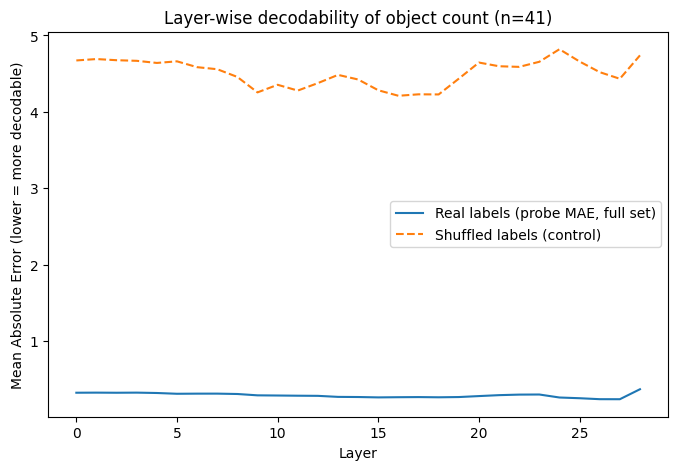

In [11]:
import json
import numpy as np
import torch
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

hidden_tensor = torch.load("data/synthetic/hidden_states_v2_qwen.pt").float()  # [41, 29, 3584]
with open("data/synthetic/results_v2_qwen.json") as f:
    results = json.load(f)

y_true = np.array([r["true_count"] for r in results])
sweep_types = np.array([r["sweep_type"] for r in results])
num_images, num_layers, hidden_dim = hidden_tensor.shape

loo = LeaveOneOut()
np.random.seed(0)
y_shuffled = y_true.copy()
np.random.shuffle(y_shuffled)

layer_mae, layer_r2, control_mae = [], [], []

for layer in range(num_layers):
    X = hidden_tensor[:, layer, :].numpy()
    preds = cross_val_predict(Ridge(alpha=1.0), X, y_true, cv=loo)
    layer_mae.append(mean_absolute_error(y_true, preds))
    layer_r2.append(r2_score(y_true, preds))
    control_preds = cross_val_predict(Ridge(alpha=1.0), X, y_shuffled, cv=loo)
    control_mae.append(mean_absolute_error(y_shuffled, control_preds))

for l in range(num_layers):
    print(f"Layer {l:2d}: probe MAE={layer_mae[l]:.2f}  R2={layer_r2[l]:.2f}  control_MAE={control_mae[l]:.2f}")

# --- Size-control subset only: directly tests the pixel-area confound ---
mask = sweep_types == "size_control"
X_size = hidden_tensor[mask][:, :, :].numpy()
y_size = y_true[mask]
print(f"\nSize-control subset: {mask.sum()} samples")

size_mae = []
for layer in range(num_layers):
    Xl = X_size[:, layer, :]
    # too few samples (5) for LOO to be meaningful on its own; report raw fit MAE as a rough signal only
    ridge = Ridge(alpha=1.0).fit(Xl, y_size)
    preds = ridge.predict(Xl)
    size_mae.append(mean_absolute_error(y_size, preds))

print("Size-control in-sample MAE by layer (rough signal only, n=5):")
for l in [0, 8, 14, 17, 20, 28]:
    print(f"  Layer {l}: {size_mae[l]:.2f}")

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(layer_mae, label="Real labels (probe MAE, full set)")
plt.plot(control_mae, label="Shuffled labels (control)", linestyle="--")
plt.xlabel("Layer")
plt.ylabel("Mean Absolute Error (lower = more decodable)")
plt.title("Layer-wise decodability of object count (n=41)")
plt.legend()
plt.savefig("results/act1_probe_curve_v2.png", dpi=150)
plt.show()

In [12]:
import gc, torch
del model, processor
gc.collect()
torch.cuda.empty_cache()

from transformers import LlavaNextForConditionalGeneration, LlavaNextProcessor, BitsAndBytesConfig

def load_llava_4bit(model_name="llava-hf/llava-v1.6-mistral-7b-hf", device="cuda"):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=False,
    )
    processor = LlavaNextProcessor.from_pretrained(model_name)
    model = LlavaNextForConditionalGeneration.from_pretrained(
        model_name, quantization_config=bnb_config, device_map="auto",
    )
    model.eval()
    return model, processor

def run_vqa_and_get_hidden_states_llava(model, processor, image, prompt="How many objects are in the image?", device="cuda"):
    conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
    text = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=image, text=text, return_tensors="pt").to(device)

    with torch.no_grad():
        fwd_out = model(**inputs, output_hidden_states=True)
    all_hidden_states = fwd_out.hidden_states

    attn_mask = inputs["attention_mask"][0]
    valid_mask = attn_mask == 1
    pooled_layers = []
    for layer_hidden in all_hidden_states:
        h = layer_hidden[0]
        valid_hidden = h[valid_mask]
        pooled = valid_hidden.mean(dim=0) if valid_hidden.shape[0] > 0 else h.mean(dim=0)
        pooled_layers.append(pooled.cpu())
    pooled_tensor = torch.stack(pooled_layers, dim=0)

    with torch.no_grad():
        gen_out = model.generate(**inputs, max_new_tokens=50)
    generated_text = processor.batch_decode(
        gen_out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]
    return generated_text, pooled_tensor

llava_model, llava_processor = load_llava_4bit()
print("LLaVA loaded")

processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

LLaVA loaded


In [13]:
import json, torch

results_llava = []
all_hidden_llava = []

for item in metadata_v2:
    img = Image.open(item["path"])
    answer, hidden = run_vqa_and_get_hidden_states_llava(llava_model, llava_processor, img)
    print(f"{item['image_id']}: true={item['count']}, sweep={item['sweep_type']}, model_said='{answer.strip()}'")
    results_llava.append({
        "image_id": item["image_id"], "true_count": item["count"],
        "occlusion_ratio": item["occlusion_ratio"], "sweep_type": item["sweep_type"],
        "model_answer": answer.strip(),
    })
    all_hidden_llava.append(hidden)

hidden_tensor_llava = torch.stack(all_hidden_llava, dim=0).float()
torch.save(hidden_tensor_llava, "data/synthetic/hidden_states_v2_llava.pt")
with open("data/synthetic/results_v2_llava.json", "w") as f:
    json.dump(results_llava, f, indent=2)
print(f"\nDone. Shape: {hidden_tensor_llava.shape}")

density_02_s0: true=2, sweep=density, model_said='There are two objects in the image.'
density_03_s0: true=3, sweep=density, model_said='There are three objects in the image.'
density_04_s0: true=4, sweep=density, model_said='There are four objects in the image.'
density_05_s0: true=5, sweep=density, model_said='There are four objects in the image.'
density_06_s0: true=6, sweep=density, model_said='There are four objects in the image.'
density_07_s0: true=7, sweep=density, model_said='There are six objects in the image.'
density_08_s0: true=8, sweep=density, model_said='There are nine objects in the image.'
density_09_s0: true=9, sweep=density, model_said='There are nine objects in the image.'
density_10_s0: true=10, sweep=density, model_said='There are six objects in the image.'
density_11_s0: true=11, sweep=density, model_said='There are six objects in the image.'
density_12_s0: true=12, sweep=density, model_said='There are nine objects in the image.'
density_13_s0: true=13, sweep=de

Layer  0: probe MAE=1.01  R2=0.88  control_MAE=3.54
Layer  1: probe MAE=1.01  R2=0.88  control_MAE=3.54
Layer  2: probe MAE=1.02  R2=0.88  control_MAE=3.54
Layer  3: probe MAE=1.02  R2=0.88  control_MAE=3.54
Layer  4: probe MAE=1.03  R2=0.88  control_MAE=3.54
Layer  5: probe MAE=1.05  R2=0.87  control_MAE=3.54
Layer  6: probe MAE=1.09  R2=0.87  control_MAE=3.53
Layer  7: probe MAE=1.13  R2=0.86  control_MAE=3.53
Layer  8: probe MAE=1.17  R2=0.85  control_MAE=3.52
Layer  9: probe MAE=1.22  R2=0.85  control_MAE=3.52
Layer 10: probe MAE=1.25  R2=0.84  control_MAE=3.51
Layer 11: probe MAE=1.30  R2=0.83  control_MAE=3.51
Layer 12: probe MAE=1.32  R2=0.82  control_MAE=3.50
Layer 13: probe MAE=1.28  R2=0.83  control_MAE=3.50
Layer 14: probe MAE=1.26  R2=0.84  control_MAE=3.49
Layer 15: probe MAE=1.20  R2=0.85  control_MAE=3.49
Layer 16: probe MAE=1.10  R2=0.87  control_MAE=3.51
Layer 17: probe MAE=1.04  R2=0.88  control_MAE=3.52
Layer 18: probe MAE=1.00  R2=0.89  control_MAE=3.51
Layer 19: pr

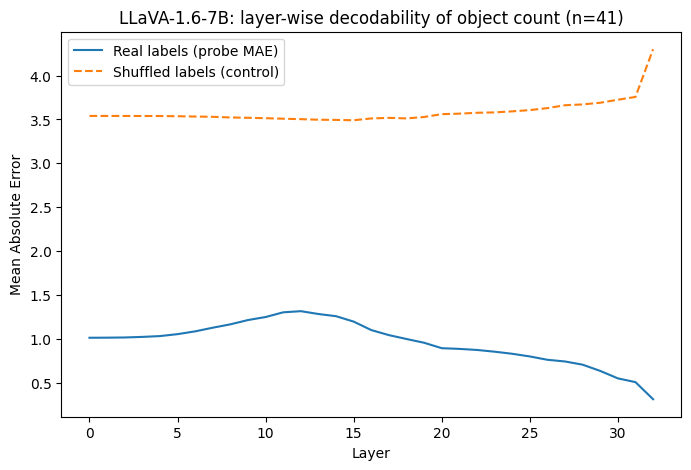

In [14]:
import json
import numpy as np
import torch
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

hidden_tensor = torch.load("data/synthetic/hidden_states_v2_llava.pt").float()  # [41, 33, 4096]
with open("data/synthetic/results_v2_llava.json") as f:
    results = json.load(f)

y_true = np.array([r["true_count"] for r in results])
num_images, num_layers, hidden_dim = hidden_tensor.shape

loo = LeaveOneOut()
np.random.seed(0)
y_shuffled = y_true.copy()
np.random.shuffle(y_shuffled)

layer_mae, layer_r2, control_mae = [], [], []
for layer in range(num_layers):
    X = hidden_tensor[:, layer, :].numpy()
    preds = cross_val_predict(Ridge(alpha=1.0), X, y_true, cv=loo)
    layer_mae.append(mean_absolute_error(y_true, preds))
    layer_r2.append(r2_score(y_true, preds))
    control_preds = cross_val_predict(Ridge(alpha=1.0), X, y_shuffled, cv=loo)
    control_mae.append(mean_absolute_error(y_shuffled, control_preds))

for l in range(num_layers):
    print(f"Layer {l:2d}: probe MAE={layer_mae[l]:.2f}  R2={layer_r2[l]:.2f}  control_MAE={control_mae[l]:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(layer_mae, label="Real labels (probe MAE)")
plt.plot(control_mae, label="Shuffled labels (control)", linestyle="--")
plt.xlabel("Layer")
plt.ylabel("Mean Absolute Error")
plt.title("LLaVA-1.6-7B: layer-wise decodability of object count (n=41)")
plt.legend()
plt.savefig("results/act1_probe_curve_llava.png", dpi=150)
plt.show()

In [15]:
import os, shutil
os.makedirs("results", exist_ok=True)
for f in ["results_v2_qwen.json", "results_v2_llava.json"]:
    shutil.move(f"data/synthetic/{f}", f"results/{f}")

!zip -r upload.zip data/synthetic/*.png data/synthetic/metadata_v2.json results/*.json results/*.png -x "data/synthetic/density_[0-9][0-9].png"

  adding: data/synthetic/density_02_s0.png (deflated 40%)
  adding: data/synthetic/density_02_s1.png (deflated 34%)
  adding: data/synthetic/density_03_s0.png (deflated 24%)
  adding: data/synthetic/density_03_s1.png (deflated 21%)
  adding: data/synthetic/density_04_s0.png (deflated 15%)
  adding: data/synthetic/density_04_s1.png (deflated 18%)
  adding: data/synthetic/density_05_s0.png (deflated 23%)
  adding: data/synthetic/density_05_s1.png (deflated 23%)
  adding: data/synthetic/density_06_s0.png (deflated 20%)
  adding: data/synthetic/density_06_s1.png (deflated 21%)
  adding: data/synthetic/density_07_s0.png (deflated 17%)
  adding: data/synthetic/density_07_s1.png (deflated 16%)
  adding: data/synthetic/density_08_s0.png (deflated 13%)
  adding: data/synthetic/density_08_s1.png (deflated 13%)
  adding: data/synthetic/density_09_s0.png (deflated 12%)
  adding: data/synthetic/density_09_s1.png (deflated 13%)
  adding: data/synthetic/density_10_s0.png (deflated 19%)
  adding: data